In [1]:
# Imports
import time
import itertools

import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from hysys import open_case, dump, members, by_component
from hysys_methanol import cache_objects, run_point

In [2]:
# KNOBS
SMOKE_TEST = False
TEMP_BOUNDS = np.array([220, 280]) # Celsius
PRESSURE_BOUNDS = np.array([70, 120]) # bar
RATIO = 3.0 # molar ratio of H2 to CO2
VOLUME = 35 # m3
PURGE_RATE = 0.03

In [3]:
# Setup
CASE = r"C:\Users\kr326\Documents\Andrea_Files_MeOH_Aspen\TestAspenFile\methanol.hsc"
t0 = time.time()
case = open_case(CASE)

print(f"Case name:        {case.Name}")
print(f"Material streams: {case.Flowsheet.MaterialStreams.Count}")
print(f"Connected in      {time.time() - t0:.1f} s")

# Cache flowsheet objects
objects = cache_objects(case)
print("Objects cached OK:")
for k in objects:
    print(f"  {k}")

Case not open in HYSYS - launching (this can take a minute)...
Case name:        Case
Material streams: 42
Connected in      25.7 s
Objects cached OK:
  solver
  units
  co2in
  h2in
  rin
  rout
  methanol
  purge
  recycle_gas
  reactor
  compressors
  split
  column
  flare
  recycle
  pressure_cell
  ratio_cell


In [4]:
def P_T_sweep():
    """Sweep Across Pressure and Temperature of the reactor."""
    results = []
    all_pressures = np.linspace(PRESSURE_BOUNDS[0], PRESSURE_BOUNDS[1], 30 if not SMOKE_TEST else 3) # [-]
    all_temperatures = np.linspace(TEMP_BOUNDS[0], TEMP_BOUNDS[1], 30 if not SMOKE_TEST else 3) # [C]

    for P, T in itertools.product(all_pressures, all_temperatures):
        print(f"Processing P={P} bar, T={T} C")
        point = dict(pressure=(P, "bar"), 
                     temperature=(T, "C"), 
                     volume=(VOLUME, "m3"),
                     purge_rate=(PURGE_RATE), 
                     ratio=(RATIO))
        try:
            results.append(run_point(objects, **point))
        except Exception as e:
            results.append(dict(temperature_set=T, pressure_set=P, converged=False, error=str(e)))

    return results
    
results = P_T_sweep()

Processing P=70.0 bar, T=220.0 C
Processing P=70.0 bar, T=222.06896551724137 C
Processing P=70.0 bar, T=224.13793103448276 C
Processing P=70.0 bar, T=226.20689655172413 C
Processing P=70.0 bar, T=228.27586206896552 C
Processing P=70.0 bar, T=230.3448275862069 C
Processing P=70.0 bar, T=232.41379310344828 C
Processing P=70.0 bar, T=234.48275862068965 C
Processing P=70.0 bar, T=236.55172413793105 C
Processing P=70.0 bar, T=238.6206896551724 C
Processing P=70.0 bar, T=240.68965517241378 C
Processing P=70.0 bar, T=242.75862068965517 C
Processing P=70.0 bar, T=244.82758620689657 C
Processing P=70.0 bar, T=246.89655172413794 C
Processing P=70.0 bar, T=248.9655172413793 C
Processing P=70.0 bar, T=251.0344827586207 C
Processing P=70.0 bar, T=253.10344827586206 C
Processing P=70.0 bar, T=255.17241379310346 C
Processing P=70.0 bar, T=257.2413793103448 C
Processing P=70.0 bar, T=259.3103448275862 C
Processing P=70.0 bar, T=261.37931034482756 C
Processing P=70.0 bar, T=263.44827586206895 C
Process

In [5]:
df = pd.DataFrame(results)
print(df.columns)

Index(['pressure_bar', 'temperature_C', 'volume_m3', 'ratio', 'purge_rate',
       'methanol_kg_h', 'hydrogen_purge_kg_h', 'co2_purge_kg_h',
       'co2_input_kg_h', 'h2_input_kg_h', 'reactor_duty_kW', 'reactor_dP_bar',
       'co_formation_kgmole_h', 'compression_kW', 'carbon_efficiency',
       'recycle_ratio', 'recycle_converged', 'column_converged',
       'recycle_iterations', 'converged', 'solve_time_s', 'timestamp'],
      dtype='str')


In [6]:
def heatmap(df, value, label, *, 
            x="pressure_bar", y="temperature_C", 
            levels=16, cmap="viridis", ax=None, title=None):
    """Heatmap of value over (x, y); non-converged cells in grey."""

    # Assert Data Validity
    if not df["converged"].all():
        print("Warning: Not all points converged")

    _df = df.copy()
    _df["value_plot"] = _df[value].where(_df["converged"])
    grid = _df.pivot(index=y, columns=x, values="value_plot")
    if ax is None:
        _, ax = plt.subplots(1, 1) 
    cmap = plt.get_cmap(cmap).copy()
    mesh = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap=cmap, shading="nearest")
    cs = ax.contour(grid.columns, grid.index, grid.values, levels=levels, colors="black", linewidths=1)
    ax.clabel(cs, fmt="%g")
    ax.set_xlabel("Pressure [bar]")
    ax.set_ylabel("T [$^\\circ{C}$]")
    ax.set_title(title)
    ax.figure.colorbar(mesh, ax=ax, label=label)

    return ax

<Axes: title={'center': 'Methanol Production'}, xlabel='Pressure [bar]', ylabel='T [$^\\circ{C}$]'>

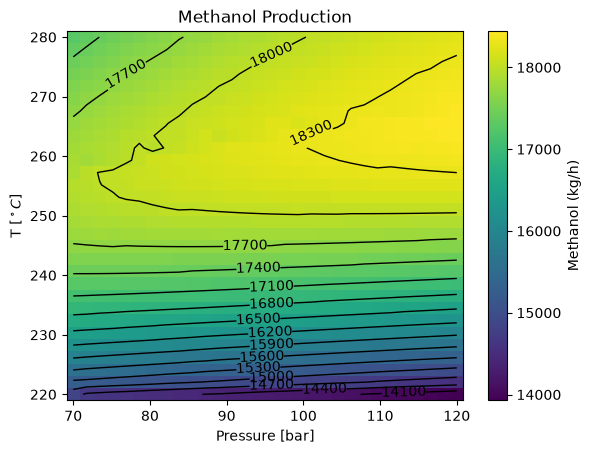

In [7]:
heatmap(df, "methanol_kg_h", "Methanol (kg/h)", title="Methanol Production", levels=15)

<Axes: title={'center': 'Recycle Ratio'}, xlabel='Pressure [bar]', ylabel='T [$^\\circ{C}$]'>

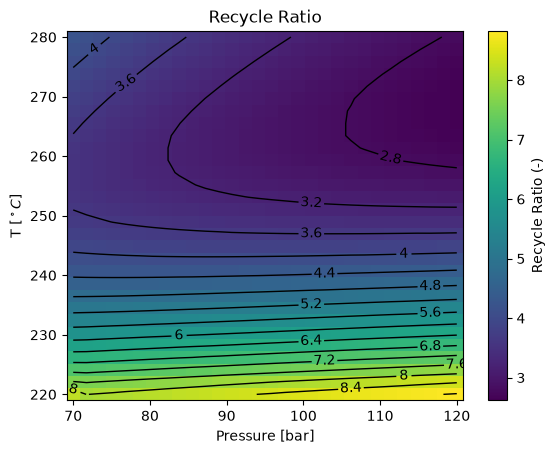

In [8]:
heatmap(df, "recycle_ratio", "Recycle Ratio (-)", title="Recycle Ratio")

<Axes: title={'center': 'Pressure Drop'}, xlabel='Pressure [bar]', ylabel='T [$^\\circ{C}$]'>

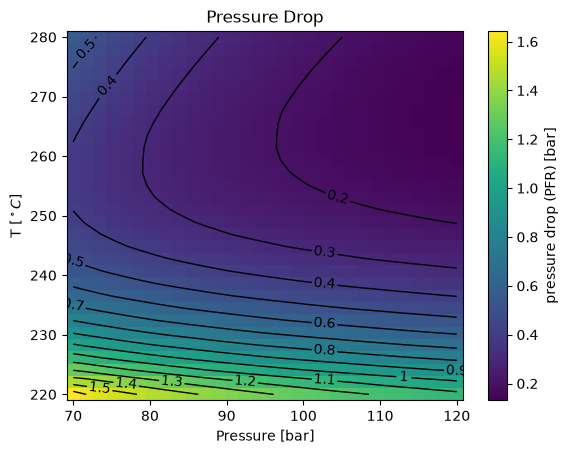

In [9]:
heatmap(df, "reactor_dP_bar", "pressure drop (PFR) [bar]", title="Pressure Drop")

<Axes: title={'center': 'CO Formation In PFR'}, xlabel='Pressure [bar]', ylabel='T [$^\\circ{C}$]'>

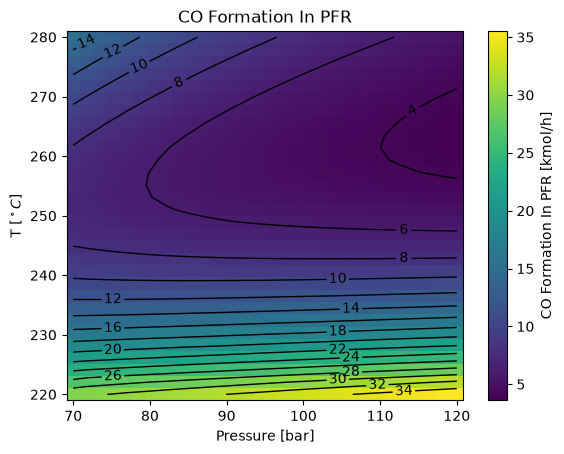

In [10]:
heatmap(df, "co_formation_kgmole_h", "CO Formation In PFR [kmol/h]", title="CO Formation In PFR") 

<Axes: title={'center': 'Compression Duty In Loop Compressors (K-100 & K-105)'}, xlabel='Pressure [bar]', ylabel='T [$^\\circ{C}$]'>

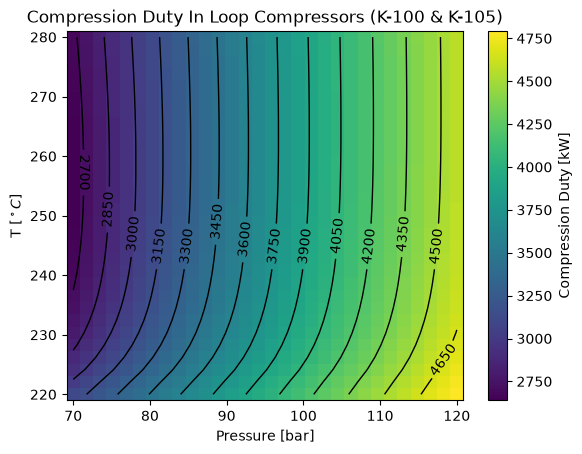

In [11]:
heatmap(df, "compression_kW", "Compression Duty [kW]", title="Compression Duty In Loop Compressors (K-100 & K-105)") 

# Decomposition Using Surrogates

In [12]:
PAR_DIM = 2 # Number of design parameters (temperature, purge-rate) -> we generate 10x more sobol points for initialization

In [13]:
# NOTE: The below is for the input variable estimation of the Reactor Inlets
U_Hull = dict(Hydrogen=[+np.inf, -np.inf], 
              CO=[+np.inf, -np.inf], 
              CO2=[+np.inf, -np.inf], 
              H2O=[+np.inf, -np.inf], 
              Methanol=[+np.inf, -np.inf], 
              Nitrogen=[+np.inf, -np.inf], 
              )

def update_U_hull(verbose: bool = True):
    """Widen the hull with the current reactor inlet flows.
    NOTE: Hull stores absolute molar flows [kmol/s]"""
    rin = objects["rin"]
    for c, flow in by_component(rin, "ComponentMolarFlow", "kgmole/s").items():
        if c in U_Hull:
            U_Hull[c][0] = min(U_Hull[c][0], flow)
            U_Hull[c][1] = max(U_Hull[c][1], flow)
    if verbose:
        print(f"P {rin.Pressure.GetValue('bar'):8.1f} bar"
              f"T {rin.Temperature.GetValue('C'):8.1f} C; ")

In [14]:
def generate_sobol_points(n: int, bounds):
    """
    n: number of points to sample
    """
    d = bounds.shape[1]
    m = int(np.ceil(np.log2(n)))
    sbsam = scipy.stats.qmc.Sobol(d=d, seed=42)
    rand_norm = sbsam.random_base2(m=m) # 2^m points
    pts = rand_norm * (bounds[1] - bounds[0]) + bounds[0]
    return pts[:n]

In [15]:
def characterize_inlet_domain():
    """Step 1) of the methodology (see PP slides)"""
    # TODO: Use the data from samples efficiently as per Benoit's suggestion
    results = []
    # all_pressures = np.linspace(PRESSURE_BOUNDS[0], PRESSURE_BOUNDS[1], 30 if not SMOKE_TEST else 3) # [-]
    # all_temperatures = np.linspace(TEMP_BOUNDS[0], TEMP_BOUNDS[1], 30 if not SMOKE_TEST else 3) # [C]
    N_PTS = PAR_DIM * 10 # heuristic for coverage
    # Design Variable (Pressure, Temperature) samples
    dvar_samples = generate_sobol_points(N_PTS, bounds=np.array([[PRESSURE_BOUNDS[0], TEMP_BOUNDS[0]], 
                                                                 [PRESSURE_BOUNDS[1], TEMP_BOUNDS[1]]]))

    for P, T in dvar_samples:
        print(f"Processing P={P} bar, T={T} C")
        point = dict(pressure=(P, "bar"),
                     temperature=(T, "C"), 
                     volume=(VOLUME, "m3"),
                     purge_rate=(PURGE_RATE),
                     ratio=(RATIO))
        try:
            result = run_point(objects, **point)
            results.append(result)
            if result["converged"]:
                update_U_hull()
        except Exception as e:
            results.append(dict(temperature_C=T, pressure_bar=P, converged=False, error=str(e)))

    return results

    # return results
characterize_inlet_domain()

Processing P=91.55147371813655 bar, T=268.86207833886147 C
P     91.6 barT    268.9 C; 
Processing P=118.07893964461982 bar, T=238.68459656834602 C
P    118.1 barT    238.7 C; 
Processing P=98.2265960238874 bar, T=255.87005829438567 C
P     98.2 barT    255.9 C; 
Processing P=71.75236607901752 bar, T=221.59055626019835 C
P     71.8 barT    221.6 C; 
Processing P=81.90336379222572 bar, T=258.3818566799164 C
P     81.9 barT    258.4 C; 
Processing P=102.13810799643397 bar, T=234.06420767307281 C
P    102.1 barT    234.1 C; 
Processing P=107.91742767207325 bar, T=275.00760486349463 C
P    107.9 barT    275.0 C; 
Processing P=87.65047600492835 bar, T=247.52452006563544 C
P     87.7 barT    247.5 C; 
Processing P=82.82182321883738 bar, T=250.91244643554091 C
P     82.8 barT    250.9 C; 
Processing P=112.5477160140872 bar, T=226.5975404344499 C
P    112.5 barT    226.6 C; 
Processing P=107.39550882019103 bar, T=267.4805162847042 C
P    107.4 barT    267.5 C; 
Processing P=77.62557704001665 b

[{'pressure_bar': 91.55147371813655,
  'temperature_C': 268.86207833886147,
  'volume_m3': 35.0,
  'ratio': 3.0,
  'purge_rate': 0.03,
  'methanol_kg_h': 18109.433427643366,
  'hydrogen_purge_kg_h': 403.75071498021464,
  'co2_purge_kg_h': 1453.6377049663122,
  'co2_input_kg_h': 28333.36205005646,
  'h2_input_kg_h': 4200.32209242474,
  'reactor_duty_kW': 9787.821031097381,
  'reactor_dP_bar': 0.23167760423893924,
  'co_formation_kgmole_h': 6.016050450550765,
  'compression_kW': 3551.41169348915,
  'carbon_efficiency': 0.8809088437582488,
  'recycle_ratio': 3.082459842759543,
  'recycle_converged': True,
  'column_converged': True,
  'recycle_iterations': 13,
  'converged': True,
  'solve_time_s': 0.4,
  'timestamp': '2026-09-17 15:39:51'},
 {'pressure_bar': 118.07893964461982,
  'temperature_C': 238.68459656834602,
  'volume_m3': 35.0,
  'ratio': 3.0,
  'purge_rate': 0.03,
  'methanol_kg_h': 16898.22465388151,
  'hydrogen_purge_kg_h': 591.939497247696,
  'co2_purge_kg_h': 2525.416990220

In [16]:
U_Hull

{'Hydrogen': [2.1251984859342516, 4.674291673577925],
 'CO': [0.03367508236333668, 0.24349863400705768],
 'CO2': [0.40357801467689874, 1.1645014828404712],
 'H2O': [0.007899254050658673, 0.010112206867473826],
 'Methanol': [0.0034198862411632196, 0.012546839052176509],
 'Nitrogen': [0.05663482154047469, 0.05877921224020832]}